In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
print("shape of dataset",df.shape)
print("columns",df.columns)
df.info()

shape of dataset (1338, 7)
columns Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [5]:
print(df.head(5))


   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [6]:
df= pd.get_dummies(df,drop_first=True)

df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [7]:
X = df.drop("charges", axis=1)
y = df["charges"]
print("x shape",X.shape)
print("y shape",y.shape)

x shape (1338, 8)
y shape (1338,)


In [8]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nTraining size",x_train.shape)
print("\nTesting size",x_test.shape)


Training size (1070, 8)

Testing size (268, 8)


In [9]:
model = LinearRegression()
model.fit(x_train, y_train)
print("Model Trained successfully")


Model Trained successfully


In [10]:
y_pred = model.predict(x_test)
y_pred[:5]

array([ 8969.55027444,  7068.74744287, 36858.41091155,  9454.67850053,
       26973.17345656])

In [11]:
r2= r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Model performance")
print("R2 score (Accuracy)",r2)
print("Mean Absolute Error",mae)
print("Mean Squared Error",mse)
print("Root Mean Squared Error",rmse)

Model performance
R2 score (Accuracy) 0.7835929767120723
Mean Absolute Error 4181.194473753654
Mean Squared Error 33596915.85136146
Root Mean Squared Error 5796.2846592762735


In [12]:
comparison = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
})
comparison.head(10)

,actual,predicted
764,9095.06825,8969.550274
887,5272.17580,7068.747443
890,29330.98315,36858.410912
1293,9301.89355,9454.678501
259,33750.29180,26973.173457
1312,4536.25900,10864.113164
899,2117.33885,170.280841
752,14210.53595,16903.450287
1286,3732.62510,1092.430936
707,10264.44210,11218.343184


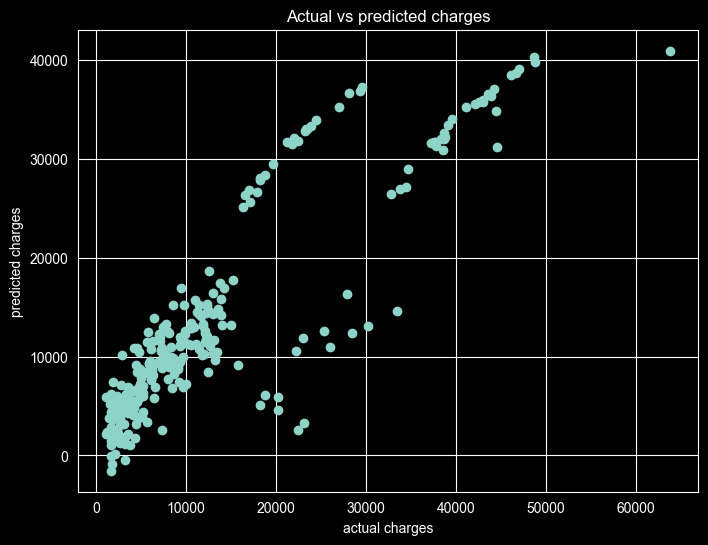

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred)
plt.xlabel("actual charges")
plt.ylabel("predicted charges")
plt.title("Actual vs predicted charges")

plt.show()

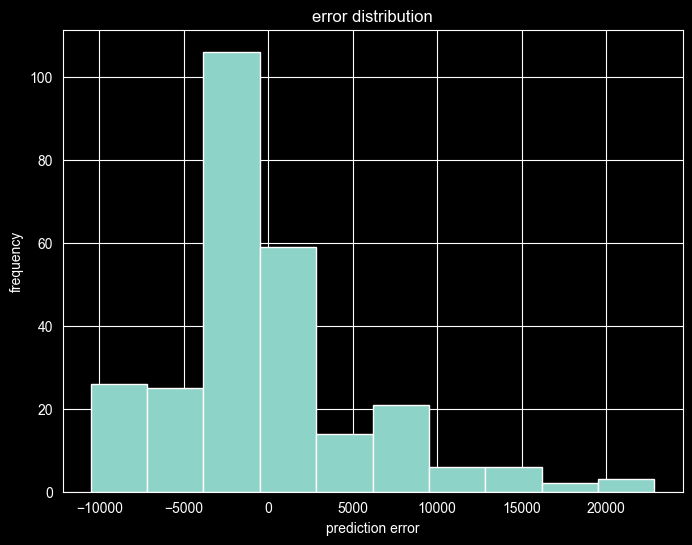

In [14]:
error = y_test - y_pred
plt.figure(figsize=(8,6))
plt.hist(error, bins=10)
plt.title("error distribution")
plt.xlabel("prediction error")
plt.ylabel("frequency")
plt.show()